In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('titanic.csv')
df.dropna(subset=['Age', 'Embarked'], inplace=True)
print(df.shape)
df.head()

(712, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'PassengerId']

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"--- {col} ---")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median()}")
    print(f"  Outliers: {len(outliers)}")
    print()

--- Age ---
  Min: 0.42
  Max: 80.0
  Mean: 29.64
  Median: 28.0
  Outliers: 8

--- Fare ---
  Min: 0.0
  Max: 512.3292
  Mean: 34.57
  Median: 15.64585
  Outliers: 95

--- SibSp ---
  Min: 0
  Max: 5
  Mean: 0.51
  Median: 0.0
  Outliers: 35

--- Parch ---
  Min: 0
  Max: 6
  Mean: 0.43
  Median: 0.0
  Outliers: 15

--- PassengerId ---
  Min: 1
  Max: 891
  Mean: 448.59
  Median: 445.0
  Outliers: 0



**Age**: Min is 0.42, Max 80, Mean is 29.6, and Median is 28. Few older passengers are outliners.
**Fare**: Min is 0.0, Max 512.3292, Mean 34.57, and Median is 15.64585. It's very skewed and has lots of high fare outliners.  
**SibSp**: Min 0, Max 8, Mean 0.5, median 0. Most people traveled alone.
**Parch**: Min 0, Max 6, mean 0.4, median 0. Most had no parents/children aboard.





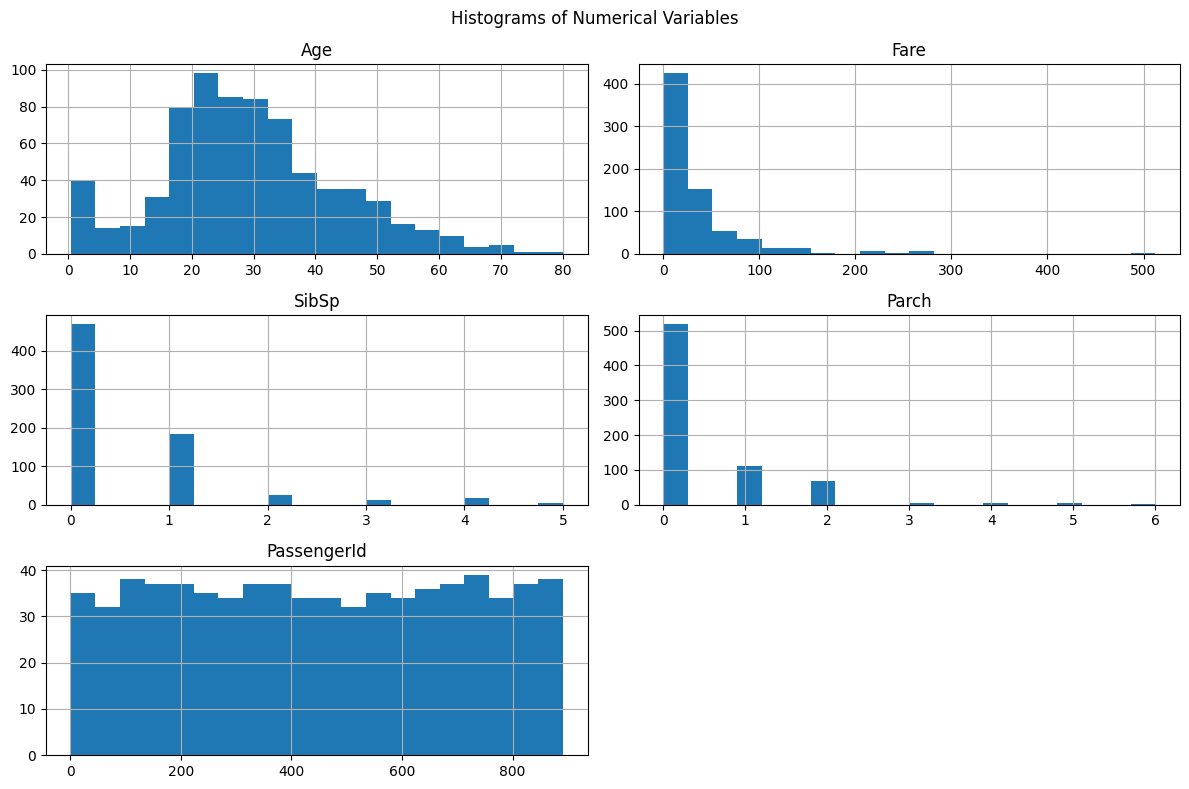

In [12]:
df[num_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle('Histograms of Numerical Variables')
plt.tight_layout()
plt.show()

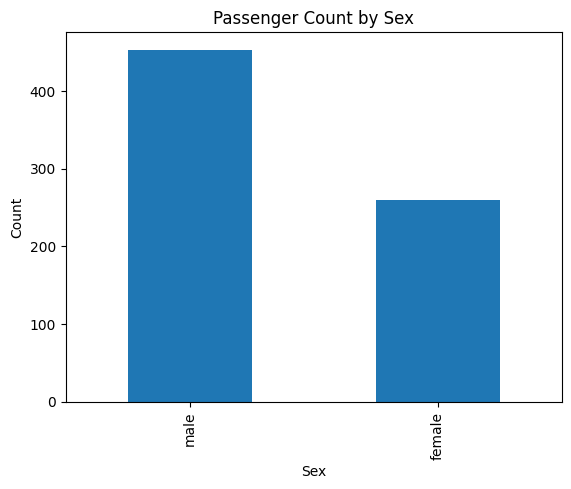

In [13]:
df['Sex'].value_counts().plot(kind='bar')
plt.title('Passenger Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

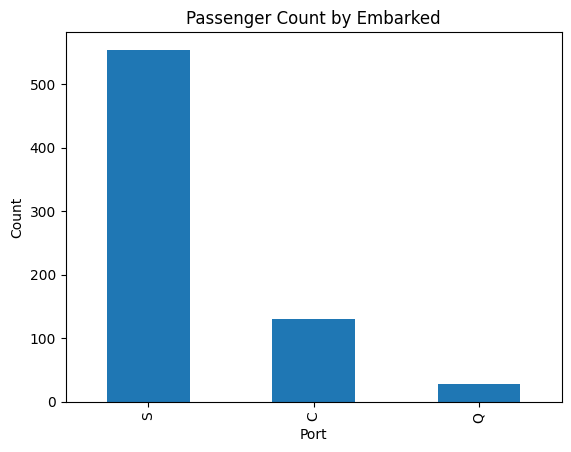

In [14]:
df['Embarked'].value_counts().plot(kind='bar')
plt.title('Passenger Count by Embarked')
plt.xlabel('Port')
plt.ylabel('Count')
plt.show()

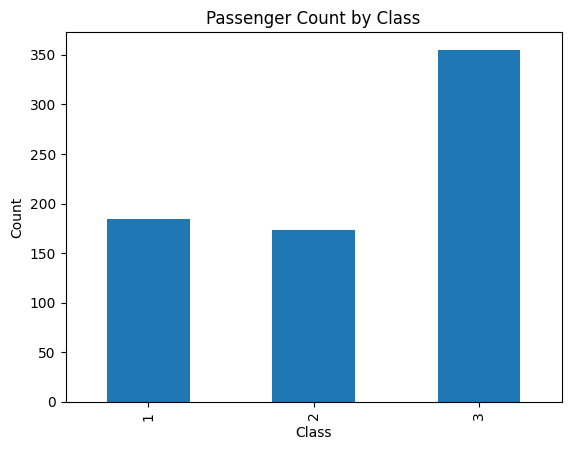

In [15]:
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Passenger Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

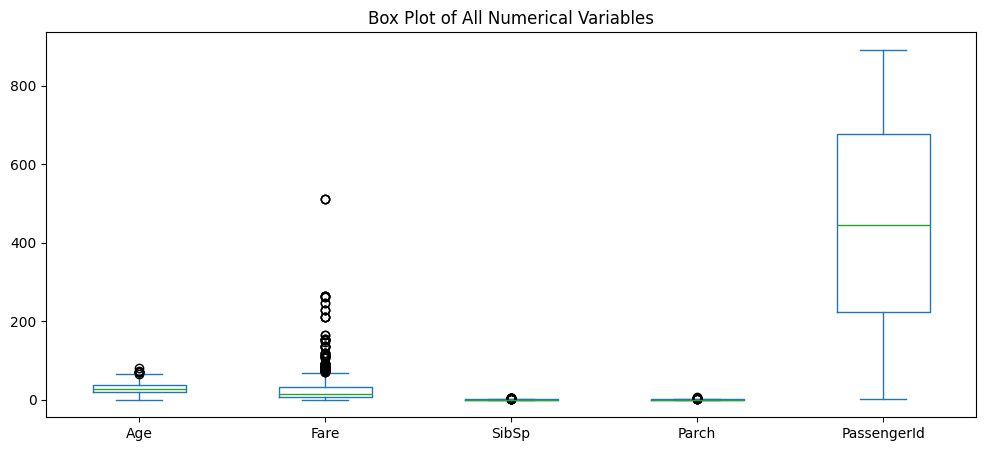

In [16]:
df[num_cols].plot(kind='box', figsize=(12, 5))
plt.title('Box Plot of All Numerical Variables')
plt.show()

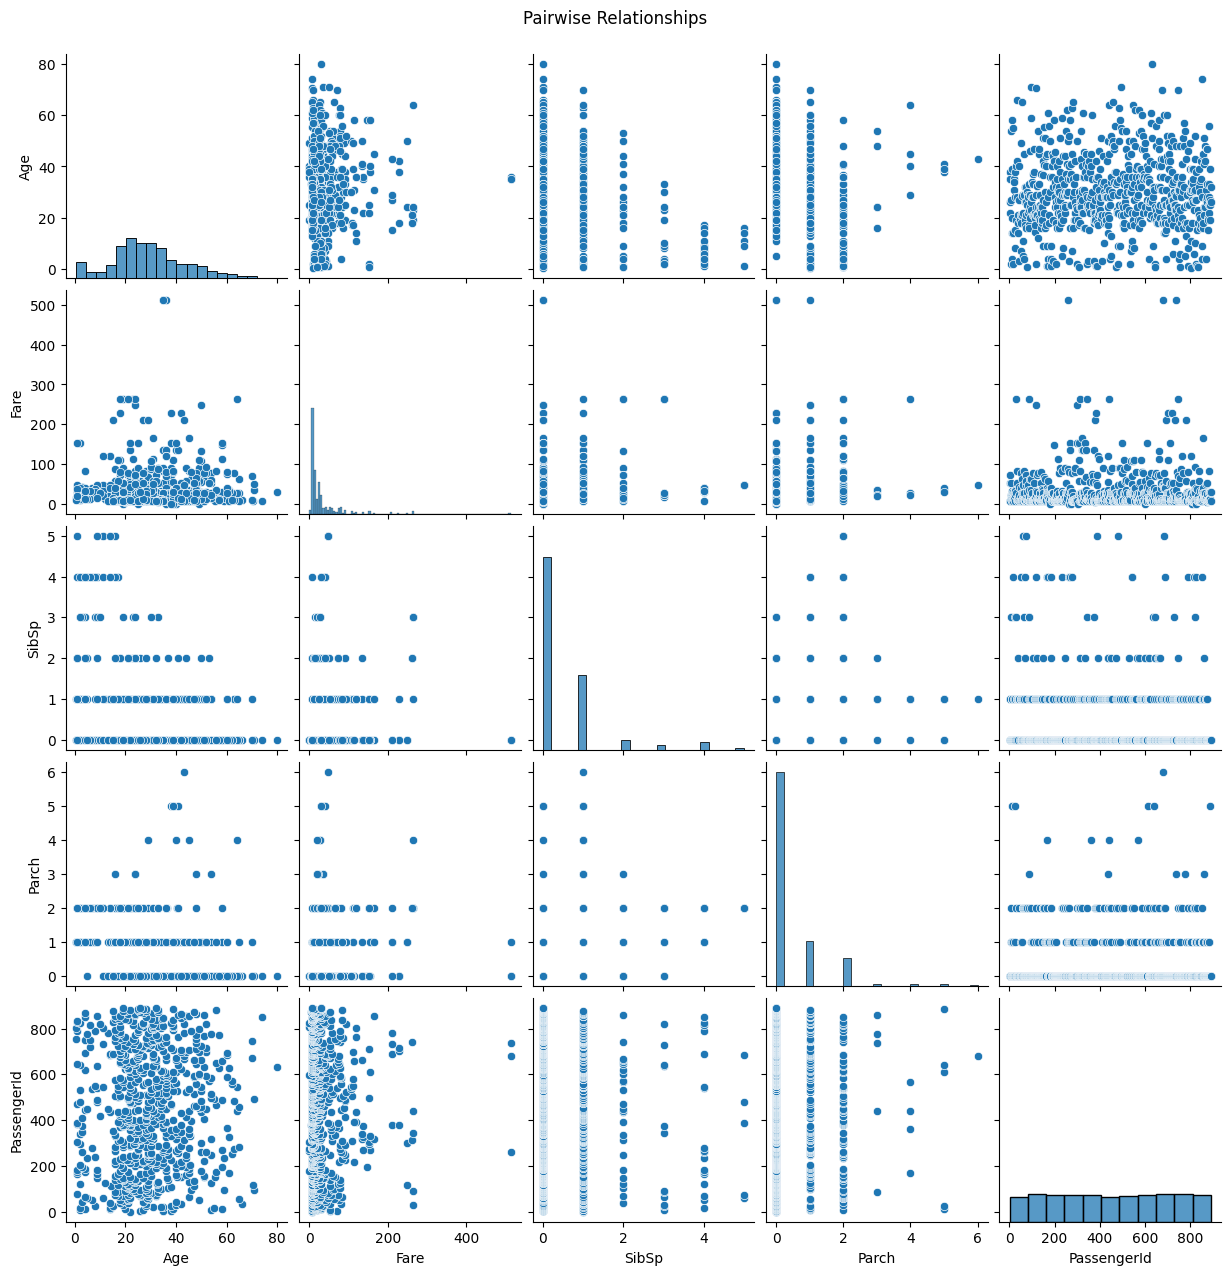

In [17]:
sns.pairplot(df[num_cols])
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

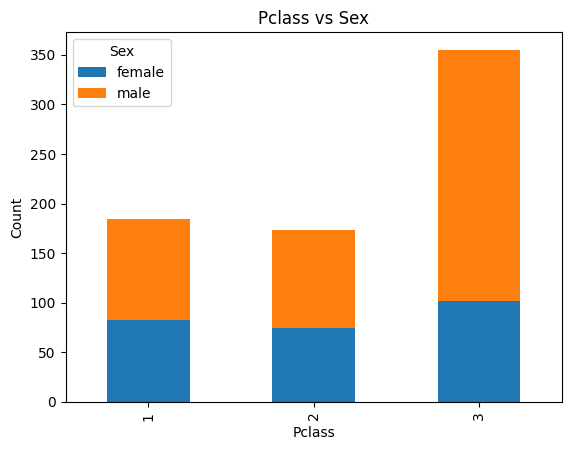

In [18]:
ct = pd.crosstab(df['Pclass'], df['Sex'])
ct.plot(kind='bar', stacked=True)
plt.title('Pclass vs Sex')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

I used a stacked bar chart to show the relationship between two categorical variables.

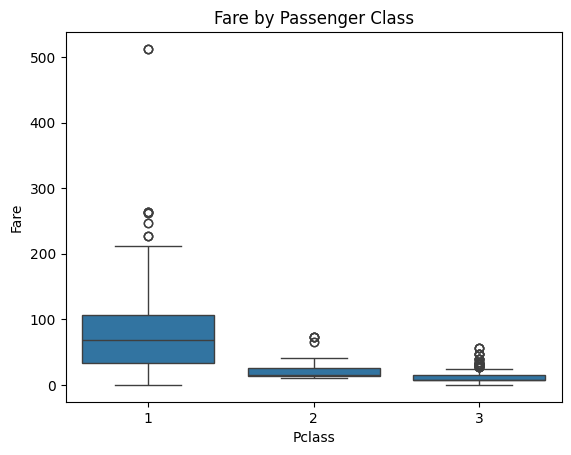

In [19]:
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title('Fare by Passenger Class')
plt.show()

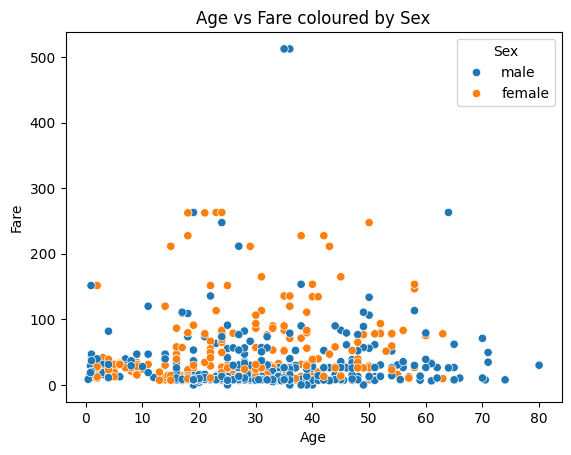

In [20]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Sex')
plt.title('Age vs Fare coloured by Sex')
plt.show()

We use color (hue) on a scatter plot to show the relationship between categorical and numerical data.